<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd, joblib, time, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
warnings.filterwarnings('ignore')
BASE = '/content/drive/MyDrive/xai-ids'
print('✅ Setup complete')

Mounted at /content/drive
✅ Setup complete


In [ ]:
# CELL 2
data    = joblib.load(f'{BASE}/data/processed/nsl_kdd_processed.pkl')
X_train = data['X_train']; X_val = data['X_val']; X_test = data['X_test']
y_train = data['y_train']; y_val  = data['y_val']; y_test = data['y_test']
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (110442, 41) | Val: (22676, 41) | Test: (22544, 41)


In [ ]:
# CELL 3
results = []

def evaluate_model(model, name, X_tr, y_tr, X_v, y_v, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    t = round(time.time()-start, 2)
    yv = model.predict(X_v)
    yt = model.predict(X_te)
    return model, {
        'model': name, 'train_time': t,
        'val_accuracy':  round(accuracy_score(y_v, yv), 4),
        'val_precision': round(precision_score(y_v, yv, average='macro', zero_division=0), 4),
        'val_recall':    round(recall_score(y_v, yv, average='macro', zero_division=0), 4),
        'val_f1':        round(f1_score(y_v, yv, average='macro', zero_division=0), 4),
        'test_accuracy': round(accuracy_score(y_te, yt), 4),
        'test_precision':round(precision_score(y_te, yt, average='macro', zero_division=0), 4),
        'test_recall':   round(recall_score(y_te, yt, average='macro', zero_division=0), 4),
        'test_f1':       round(f1_score(y_te, yt, average='macro', zero_division=0), 4),
    }, yt

print('✅ Evaluation helper ready')

✅ Evaluation helper ready


In [ ]:
# CELL 4 — Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model, nb_metrics, nb_pred = evaluate_model(GaussianNB(), 'Naive Bayes', X_train, y_train, X_val, y_val, X_test, y_test)
results.append(nb_metrics)
print(f'Naive Bayes  — val F1: {nb_metrics["val_f1"]}  test F1: {nb_metrics["test_f1"]}  time: {nb_metrics["train_time"]}s')

Naive Bayes  — val F1: 0.8942  test F1: 0.7717  time: 0.1s


k= 1: val F1 = 0.9976
k= 3: val F1 = 0.9968
k= 5: val F1 = 0.9961
k= 7: val F1 = 0.9953
k= 9: val F1 = 0.9952
k=11: val F1 = 0.9949
k=15: val F1 = 0.9945

✅ Best k=1


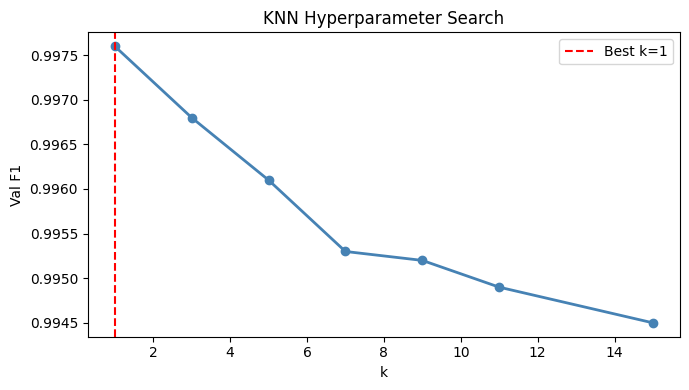

In [ ]:
# CELL 5 — KNN hyperparameter search
from sklearn.neighbors import KNeighborsClassifier
k_results = []
for k in [1,3,5,7,9,11,15]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    f1 = f1_score(y_val, knn.predict(X_val), average='macro')
    k_results.append({'k':k,'val_f1':round(f1,4)})
    print(f'k={k:2d}: val F1 = {f1:.4f}')

best_k = max(k_results, key=lambda x: x['val_f1'])['k']
print(f'\n✅ Best k={best_k}')
knn_model, knn_metrics, knn_pred = evaluate_model(
    KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1), f'KNN (k={best_k})',
    X_train, y_train, X_val, y_val, X_test, y_test)
results.append(knn_metrics)

import pandas as pd
k_df = pd.DataFrame(k_results)
plt.figure(figsize=(7,4))
plt.plot(k_df['k'], k_df['val_f1'], 'o-', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('Val F1'); plt.title('KNN Hyperparameter Search'); plt.legend()
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/knn_k_search.png', dpi=300); plt.show()

In [ ]:
# CELL 6 — SVM
from sklearn.svm import SVC
print('Training SVM — may take several minutes...')
svm_model, svm_metrics, svm_pred = evaluate_model(
    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42), 'SVM (RBF)',
    X_train, y_train, X_val, y_val, X_test, y_test)
results.append(svm_metrics)
print(f'SVM — val F1: {svm_metrics["val_f1"]}  test F1: {svm_metrics["test_f1"]}  time: {svm_metrics["train_time"]}s')

Training SVM — may take several minutes...
SVM — val F1: 0.9925  test F1: 0.7813  time: 410.58s


In [ ]:
# CELL 7 — Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model, rf_metrics, rf_pred = evaluate_model(
    RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1), 'Random Forest',
    X_train, y_train, X_val, y_val, X_test, y_test)
results.append(rf_metrics)
print(f'RF — val F1: {rf_metrics["val_f1"]}  test F1: {rf_metrics["test_f1"]}  time: {rf_metrics["train_time"]}s')

RF — val F1: 0.9989  test F1: 0.7685  time: 21.27s


Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9712 - loss: 0.0809 - val_accuracy: 0.9670 - val_loss: 0.0886
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9878 - loss: 0.0352 - val_accuracy: 0.9850 - val_loss: 0.0421
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9892 - loss: 0.0296 - val_accuracy: 0.9904 - val_loss: 0.0310
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9905 - loss: 0.0266 - val_accuracy: 0.9899 - val_loss: 0.0278
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9917 - loss: 0.0235 - val_accuracy: 0.9882 - val_loss: 0.0274
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9922 - loss: 0.0226 - val_accuracy: 0.9902 - val_loss: 0.0263
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9927 - loss: 0.0204 - val_accuracy: 0.9943 - val_loss: 0.0173
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.9934 - loss: 0.0193 - 

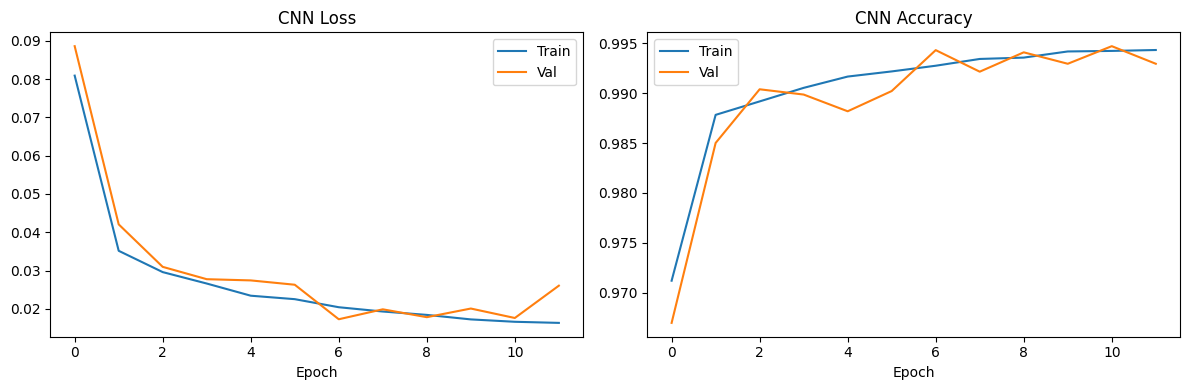

In [ ]:
# CELL 8 — 1D CNN (all metrics properly computed)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

def build_cnn(n):
    m = keras.Sequential([
        layers.Input(shape=(n,)), layers.Reshape((n,1)),
        layers.Conv1D(64, 3, activation='relu', padding='same'), layers.BatchNormalization(), layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu', padding='same'), layers.BatchNormalization(), layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'), layers.Dropout(0.3), layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

cnn = build_cnn(X_train.shape[1])
es  = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
t0  = time.time()
history = cnn.fit(X_train, y_train, validation_data=(X_val,y_val),
                  epochs=30, batch_size=256, callbacks=[es], verbose=1)
cnn_time = round(time.time()-t0, 2)

yv_cnn = (cnn.predict(X_val,  verbose=0) > 0.5).astype(int).flatten()
yt_cnn = (cnn.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

cnn_metrics = {
    'model':'1D CNN', 'train_time': cnn_time,
    'val_accuracy':  round(accuracy_score(y_val, yv_cnn), 4),
    'val_precision': round(precision_score(y_val, yv_cnn, average='macro', zero_division=0), 4),
    'val_recall':    round(recall_score(y_val, yv_cnn, average='macro', zero_division=0), 4),
    'val_f1':        round(f1_score(y_val, yv_cnn, average='macro', zero_division=0), 4),
    'test_accuracy': round(accuracy_score(y_test, yt_cnn), 4),
    'test_precision':round(precision_score(y_test, yt_cnn, average='macro', zero_division=0), 4),
    'test_recall':   round(recall_score(y_test, yt_cnn, average='macro', zero_division=0), 4),
    'test_f1':       round(f1_score(y_test, yt_cnn, average='macro', zero_division=0), 4),
}
results.append(cnn_metrics)
print(f'\nCNN — val F1: {cnn_metrics["val_f1"]}  test F1: {cnn_metrics["test_f1"]}  time: {cnn_time}s')

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['loss'], label='Train'); axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('CNN Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train'); axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('CNN Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/cnn_learning_curves.png', dpi=300); plt.show()
cnn.save(f'{BASE}/results/models/cnn_model.h5')

In [ ]:
# CELL 9 — Results table
import pandas as pd
results_df = pd.DataFrame(results).sort_values('test_f1', ascending=False)
print('='*90)
print(results_df[['model','train_time','val_f1','test_accuracy','test_precision','test_recall','test_f1']].to_string(index=False))
print('='*90)
print('\nOverfitting check (val vs test F1 gap):')
for _, row in results_df.iterrows():
    if isinstance(row['val_f1'], float) and row['val_f1'] > 0:
        gap = row['val_f1'] - row['test_f1']
        print(f"  {row['model']:20s}: gap={gap:+.4f}  {'⚠️ overfit' if gap>0.15 else '✅'}")
results_df.to_csv(f'{BASE}/results/metrics/model_comparison.csv', index=False)
print('✅ Results saved')

        model  train_time  val_f1  test_accuracy  test_precision  test_recall  test_f1
       1D CNN      349.30  0.9943         0.7889          0.8190       0.8099   0.7886
    SVM (RBF)      410.58  0.9925         0.7821          0.8219       0.8060   0.7813
  Naive Bayes        0.10  0.8942         0.7717          0.7917       0.7890   0.7717
Random Forest       21.27  0.9989         0.7695          0.8119       0.7941   0.7685
    KNN (k=1)        0.01  0.9976         0.7653          0.8113       0.7909   0.7640

Overfitting check (val vs test F1 gap):
  1D CNN              : gap=+0.2057  ⚠️ overfit
  SVM (RBF)           : gap=+0.2112  ⚠️ overfit
  Naive Bayes         : gap=+0.1225  ✅
  Random Forest       : gap=+0.2304  ⚠️ overfit
  KNN (k=1)           : gap=+0.2336  ⚠️ overfit
✅ Results saved


In [ ]:
# CELL 10 — Save models
joblib.dump(nb_model,  f'{BASE}/results/models/naive_bayes.pkl')
joblib.dump(knn_model, f'{BASE}/results/models/knn.pkl')
joblib.dump(svm_model, f'{BASE}/results/models/svm.pkl')
joblib.dump(rf_model,  f'{BASE}/results/models/random_forest.pkl')
print('✅ All models saved')

✅ All models saved


In [ ]:
# CELL 11 — Classification reports
model_preds = {'Naive Bayes':nb_pred, f'KNN (k={best_k})':knn_pred,
               'SVM (RBF)':svm_pred, 'Random Forest':rf_pred, '1D CNN':yt_cnn}
for name, preds in model_preds.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, preds, target_names=['Normal','Attack']))


--- Naive Bayes ---
              precision    recall  f1-score   support

      Normal       0.67      0.91      0.78      9711
      Attack       0.91      0.66      0.77     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.81      0.77      0.77     22544


--- KNN (k=1) ---
              precision    recall  f1-score   support

      Normal       0.65      0.98      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.77      0.76     22544


--- SVM (RBF) ---
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.79      9711
      Attack       0.97      0.63      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg   

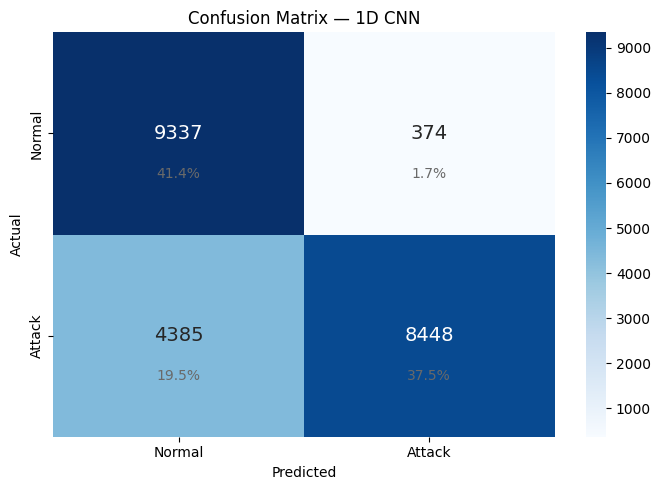

In [ ]:
# CELL 12 — Confusion matrix best model
best_name  = results_df.iloc[0]['model']
best_preds = model_preds[best_name]
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], annot_kws={'size':14})
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'{cm[i,j]/cm.sum():.1%}', ha='center', color='dimgray', fontsize=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/confusion_matrix.png', dpi=300); plt.show()